# 🎓 AI-Powered Lead Scoring and Conversion Prediction System

### Internship Project
**Organization:** Celebal Technologies

### Problem Statement
Lead scoring is a process of assigning scores to prospects based on their profile and behavioral data in order to prioritize leads, improve close rates, and decrease buying cycles.

An education company named X Education sells online courses to industry professionals. On any given day, many professionals who are interested in the courses land on their website and browse for courses.

The company markets its courses on several websites and search engines like Google. Once these people land on the website, they might browse the courses or fill up a form for the course or watch some videos. When these people fill up a form providing their email address or phone number, they are classified to be a lead. Moreover, the company also gets leads through past referrals. Once these leads are acquired, employees from the sales team start making calls, writing emails, etc. Through this process, some of the leads get converted while most do not.

The typical lead conversion rate at X education is around 30%.

Now, although X Education gets a lot of leads, its lead conversion rate is very poor. To make this process more efficient, the company wishes to identify the most potential leads, also known as ‘Hot Leads’.

If they successfully identify this set of leads, the lead conversion rate should go up as the sales team will now be focusing more on communicating with the potential leads rather than making calls to everyone.

There are a lot of leads generated in the initial stage (top) but only a few of them come out as paying customers from the bottom. In the middle stage, you need to nurture the potential leads well (i.e. educating the leads about the product, constantly communicating, etc. ) in order to get a higher lead conversion.

### Business Goal

**Goal from a business perspective:**

X Education wants to select the most promising leads, i.e. the leads that are most likely to convert into paying customers. The company requires you to build a model wherein you need to assign a lead score to each of the leads such that the customers with higher lead score have a higher conversion chance and the customers with lower lead score have a lower conversion chance. The CEO, in particular, has given a ballpark of the target lead conversion rate to be around 80%.

**Goal from a Data Scientist perspective:**

Our mission is to build a better lead scoring model, targeting an 80% conversion rate and precision score. Using predict_proba(), we'll assess lead probabilities. This project aims to gain insights and emphasize a data-driven approach for success.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 📂 Project Setup

In this section, we define the project paths and organize the project directories for storing datasets, generated outputs, visualizations, and trained models.

In [2]:
PROJECT_PATH = "/content/drive/MyDrive/Celebal_Final_Project"
DATA_PATH = f"{PROJECT_PATH}/data"
OUTPUT_PATH = f"{PROJECT_PATH}/outputs"
FIGURE_PATH = f"{OUTPUT_PATH}/figures"

In [3]:
!pip install xgboost shap openpyxl -q

# 📚 Importing Required Libraries

The project requires libraries for:

- Data manipulation and analysis
- Data visualization
- Data preprocessing
- Machine learning model development
- Model evaluation
- Saving trained models

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import *

import joblib

# 📥 Loading Dataset

The Lead Scoring dataset contains information about prospective customers including:

- Lead source
- Website activities
- Occupation
- Last interactions
- Customer profile information
- Conversion status

The target variable is:

**Converted**
- 1 → Lead Converted
- 0 → Lead Not Converted

In [5]:
#Load Dataset
df = pd.read_csv(f"{DATA_PATH}/Lead Scoring.csv")

# 🔍 First Look at the Dataset

Before performing any preprocessing, it is important to understand:

- Number of observations
- Number of features
- Data types
- Missing values
- General structure of the dataset

In [6]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

# 📊 Dataset Dimensions

We will determine:

- Total number of rows
- Total number of columns
- Number of numerical variables
- Number of categorical variables

In [7]:
rows, cols = df.shape

cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

print(f"Rows : {rows}")
print(f"Columns : {cols}")
print(f"Categorical Features : {len(cat_cols)}")
print(f"Numerical Features : {len(num_cols)}")

Rows : 9240
Columns : 37
Categorical Features : 30
Numerical Features : 7


# 🎯 Understanding the Target Variable

The target variable is **Converted**.

Understanding the distribution of converted and non-converted leads is important because:

- It helps identify class imbalance.
- It provides the baseline conversion rate.
- It indicates the business challenge faced by X Education.

In [8]:
df['Converted'].value_counts()

,count
Converted,
0,5679
1,3561


In [9]:
conversion_rate = (df['Converted'].value_counts(normalize=True)* 100)
conversion_rate

,proportion
Converted,
0,61.461039
1,38.538961


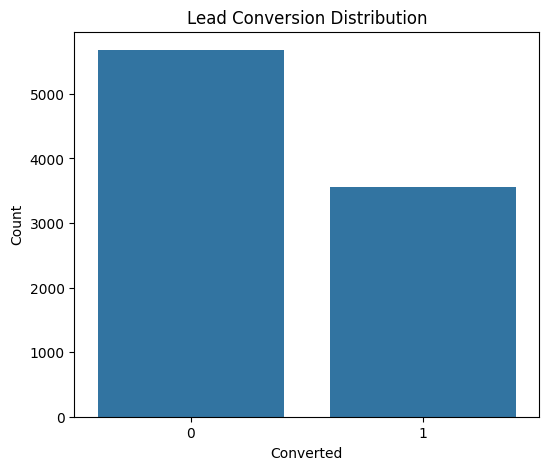

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(x='Converted',data=df)

plt.title('Lead Conversion Distribution')
plt.xlabel('Converted')
plt.ylabel('Count')

plt.show()

## 📌 Observation

The dataset shows that a significantly larger proportion of leads did not convert compared to those that converted.

## 💡 Business Insight

The current lead conversion rate is relatively low, indicating that the sales team spends considerable effort on leads that are unlikely to become paying customers.

This justifies the need for a Lead Scoring System capable of identifying high-potential leads and prioritizing sales efforts effectively.

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Lead Number,9240.0,617188.435606,23405.995698,579533.0,596484.5,615479.0,637387.25,660737.0
Converted,9240.0,0.385390,0.486714,0.0,0.0,0.0,1.00,1.0
TotalVisits,9103.0,3.445238,4.854853,0.0,1.0,3.0,5.00,251.0
Total Time Spent on Website,9240.0,487.698268,548.021466,0.0,12.0,248.0,936.00,2272.0
Page Views Per Visit,9103.0,2.362820,2.161418,0.0,1.0,2.0,3.00,55.0
Asymmetrique Activity Score,5022.0,14.306252,1.386694,7.0,14.0,14.0,15.00,18.0
Asymmetrique Profile Score,5022.0,16.344883,1.811395,11.0,15.0,16.0,18.00,20.0


# 🔎 Missing Value Analysis

Real-world business datasets often contain incomplete information.

Before cleaning the dataset, we need to:

- Identify columns containing missing values
- Measure the percentage of missing data
- Determine whether columns should be imputed or removed
- Understand the business significance of missing information

In [12]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage': missing_percent
})

missing_df = (missing_df.sort_values(by='Percentage',ascending=False))

missing_df

,Missing Values,Percentage
Lead Quality,4767,51.590909
Asymmetrique Profile Index,4218,45.649351
Asymmetrique Activity Score,4218,45.649351
Asymmetrique Activity Index,4218,45.649351
Asymmetrique Profile Score,4218,45.649351
Tags,3353,36.287879
What matters most to you in choosing a course,2709,29.318182
Lead Profile,2709,29.318182
What is your current occupation,2690,29.112554
Country,2461,26.634199


# 📊 Visualizing Missing Values

Visualizing missing values helps in quickly identifying features with substantial missing information and deciding the appropriate treatment strategy.

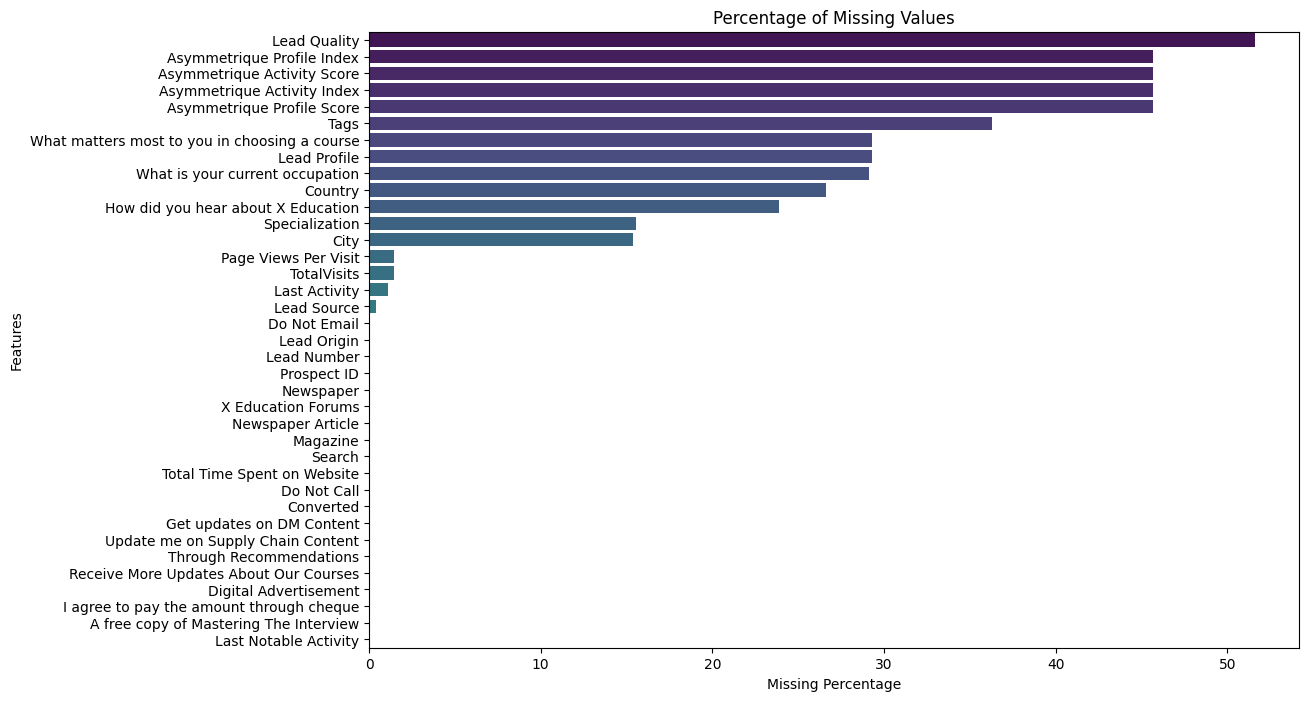

In [13]:
plt.figure(figsize=(12,8))

sns.barplot(
    x='Percentage',
    y=missing_df.index,
    data=missing_df,
    palette='viridis'
)

plt.title('Percentage of Missing Values')
plt.xlabel('Missing Percentage')
plt.ylabel('Features')

plt.show()

## 📌 Observation

Some variables contain very high percentages of missing values, while others have relatively few missing entries.

## 💡 Business Insight

Columns with extremely high missing percentages may contribute little predictive information and can increase model complexity.

Columns with moderate missing values may still be valuable and should be carefully imputed rather than immediately discarded.

# 🏷️ Understanding Feature Types

Different preprocessing techniques are required for numerical and categorical variables.

Therefore, we separate features into:

- Numerical Features
- Categorical Features

In [14]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

num_cols = df.select_dtypes(exclude='object').columns.tolist()

print("Categorical Features :", len(cat_cols))
print("Numerical Features :", len(num_cols))
print("Categorical Features\n")
print(cat_cols)
print("\n")
print("Numerical Features\n")
print(num_cols)

Categorical Features : 30
Numerical Features : 7
Categorical Features

['Prospect ID', 'Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']


Numerical Features

['Lead Number', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']


# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the underlying patterns, relationships, and trends within the dataset.

The objectives of this section are:

- Analyze the distribution of important features.
- Understand factors affecting lead conversion.
- Identify business insights.
- Discover variables that are likely to influence the predictive model.

## 1️⃣ Lead Origin Analysis

Lead Origin indicates the channel through which a customer entered the sales funnel.

Understanding which origin generates more converted leads helps the marketing team invest in the most effective acquisition channels.

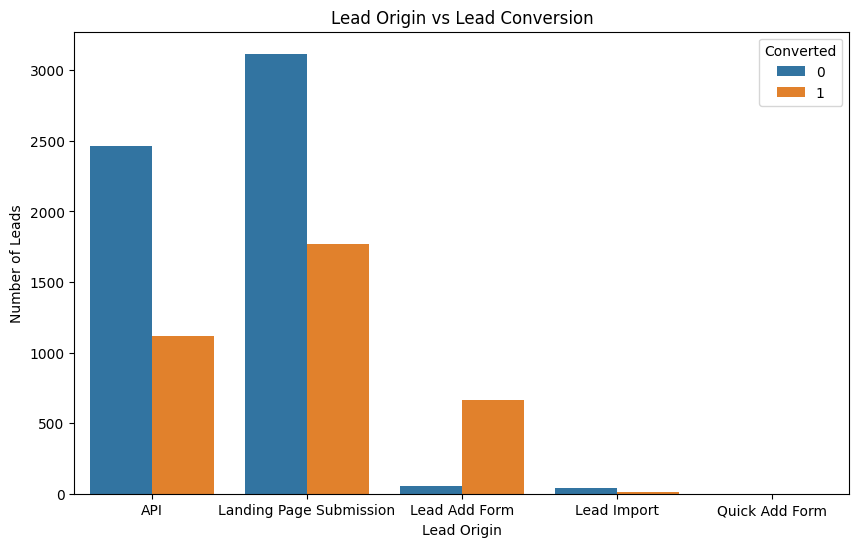

In [15]:
plt.figure(figsize=(10,6))

sns.countplot(data=df,x='Lead Origin',hue='Converted')

plt.title("Lead Origin vs Lead Conversion")
plt.xlabel("Lead Origin")
plt.ylabel("Number of Leads")

plt.show()

In [16]:
pd.crosstab(df['Lead Origin'],df['Converted'],normalize='index').round(2) * 100

Converted,0,1
Lead Origin,,
API,69.0,31.0
Landing Page Submission,64.0,36.0
Lead Add Form,8.0,92.0
Lead Import,76.0,24.0
Quick Add Form,0.0,100.0


### 📌 Observation

- Compare the conversion percentage across different Lead Origins.
- Identify which origin contributes the highest number of converted leads.

### 💼 Business Insight

The sales and marketing teams should allocate more budget and effort toward acquisition channels that consistently produce high-conversion leads.

## 2️⃣ Lead Source Analysis

Lead Source represents the specific platform from which a lead was acquired (e.g., Google, Organic Search, Direct Traffic).

Analyzing Lead Source helps identify the most effective marketing channels.

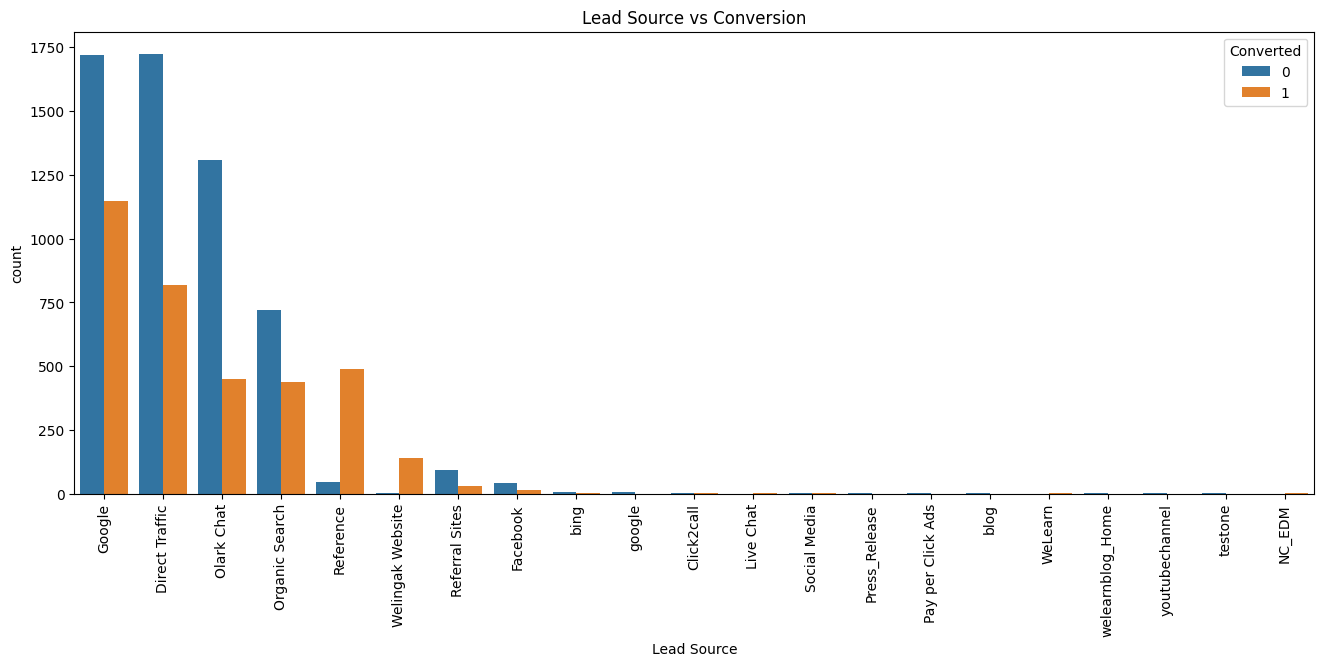

In [17]:
plt.figure(figsize=(16,6))
sns.countplot(data=df,x='Lead Source',hue='Converted',order=df['Lead Source'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Lead Source vs Conversion")
plt.show()

In [18]:
pd.crosstab(df['Lead Source'],df['Converted'],normalize='index').round(2) * 100

Converted,0,1
Lead Source,,
Click2call,25.0,75.0
Direct Traffic,68.0,32.0
Facebook,76.0,24.0
Google,60.0,40.0
Live Chat,0.0,100.0
NC_EDM,0.0,100.0
Olark Chat,74.0,26.0
Organic Search,62.0,38.0
Pay per Click Ads,100.0,0.0


### 📌 Observation

Identify the lead sources that contribute the highest number of successful conversions.

### 💼 Business Insight

Marketing campaigns should prioritize high-performing lead sources while optimizing or reducing investment in low-performing channels.

## 3️⃣ Website Engagement Analysis

One of the strongest indicators of customer interest is the amount of time spent on the website.

Customers spending more time are generally more engaged with the offered courses.

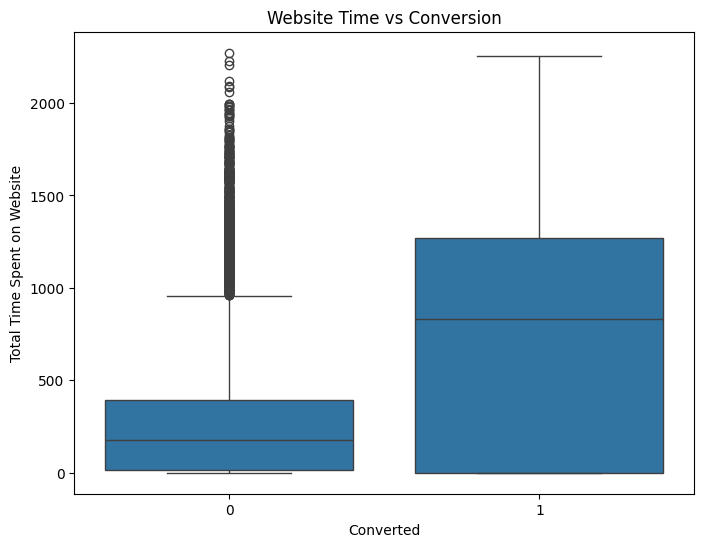

In [19]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Converted',
    y='Total Time Spent on Website'
)

plt.title("Website Time vs Conversion")

plt.show()

### 📌 Observation

Compare the distribution of website time between converted and non-converted leads.

### 💼 Business Insight

If converted customers spend significantly more time on the website, this feature is likely to be an important predictor for lead scoring.

## 4️⃣ Total Website Visits Analysis

Frequent visits often indicate a customer's growing interest in the offered courses.

Analyzing visit frequency helps understand customer engagement.

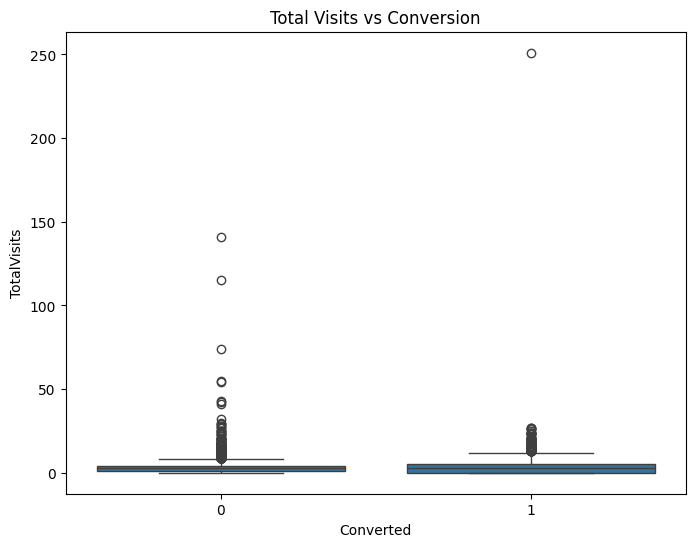

In [20]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Converted',
    y='TotalVisits'
)

plt.title("Total Visits vs Conversion")

plt.show()

### 📌 Observation

Analyze whether converted customers tend to visit the website more frequently than non-converted customers.

### 💼 Business Insight

Highly engaged visitors are more likely to become paying customers and should receive greater attention from the sales team.

## 5️⃣ Last Activity Analysis

The **Last Activity** feature represents the most recent interaction performed by a lead, such as opening an email, visiting the website, filling a form, or chatting with the sales team.

Understanding customer activity helps identify behavioral patterns that influence conversion.

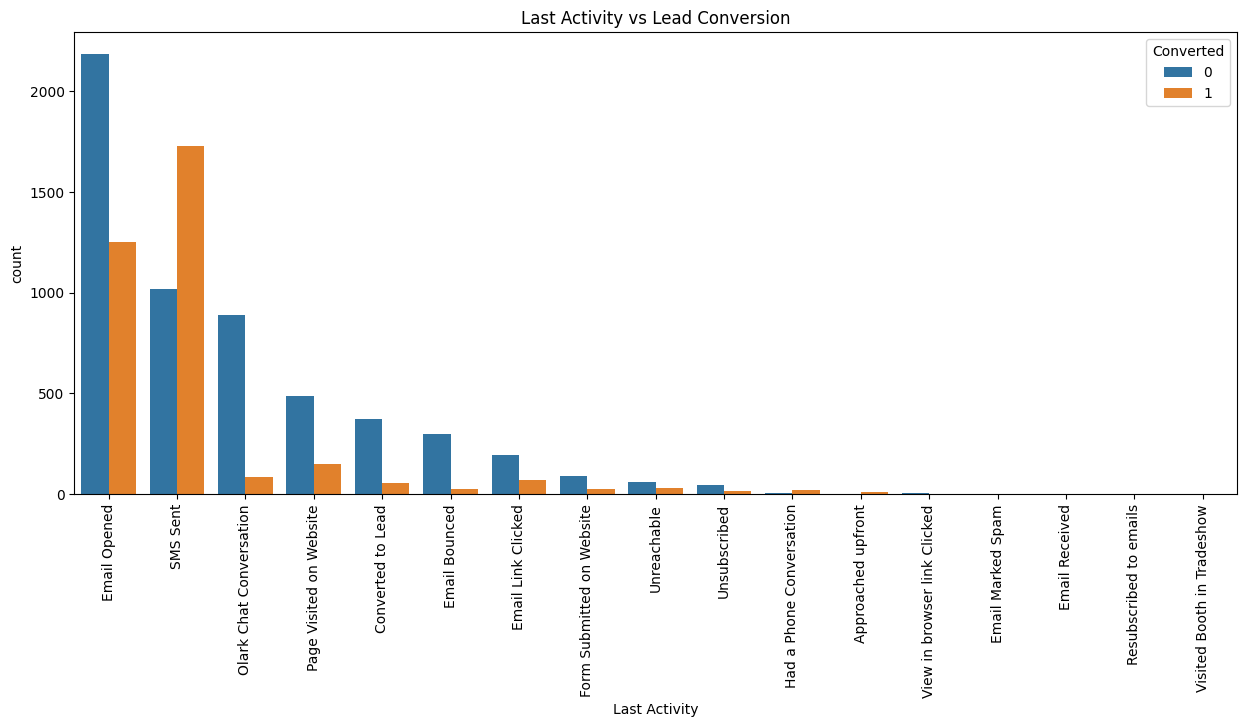

In [21]:
plt.figure(figsize=(15,6))

order = df['Last Activity'].value_counts().index

sns.countplot(
    data=df,
    x='Last Activity',
    hue='Converted',
    order=order
)

plt.xticks(rotation=90)
plt.title("Last Activity vs Lead Conversion")

plt.show()

In [22]:
pd.crosstab(
    df['Last Activity'],
    df['Converted'],
    normalize='index'
).round(2) * 100

Converted,0,1
Last Activity,,
Approached upfront,0.0,100.0
Converted to Lead,87.0,13.0
Email Bounced,92.0,8.0
Email Link Clicked,73.0,27.0
Email Marked Spam,0.0,100.0
Email Opened,64.0,36.0
Email Received,0.0,100.0
Form Submitted on Website,76.0,24.0
Had a Phone Conversation,27.0,73.0


### 📌 Observation

- Identify activities associated with higher conversion rates.
- Compare customer behavior before conversion.

### 💼 Business Insight

The sales team can prioritize leads based on their most recent activity. Certain activities indicate stronger purchase intent than others.

## 6️⃣ Current Occupation Analysis

The customer's current occupation may influence their likelihood of enrolling in an online course.

Understanding occupation-wise conversion helps identify high-value customer segments.

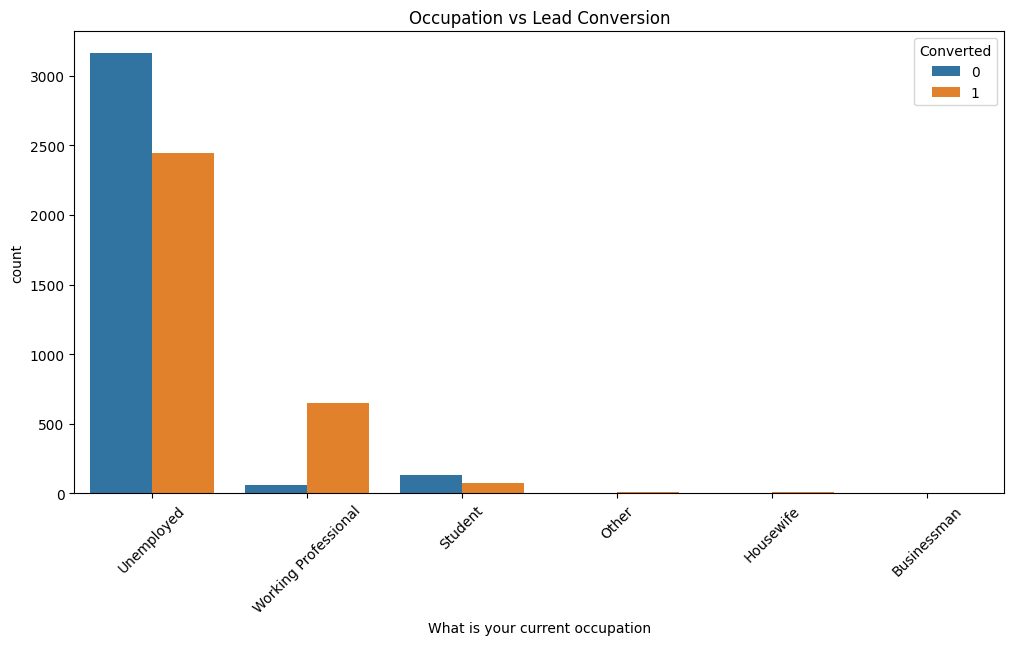

In [23]:
plt.figure(figsize=(12,6))

order = df['What is your current occupation'].value_counts().index

sns.countplot(
    data=df,
    x='What is your current occupation',
    hue='Converted',
    order=order
)

plt.xticks(rotation=45)
plt.title("Occupation vs Lead Conversion")

plt.show()

In [24]:
pd.crosstab(
    df['What is your current occupation'],
    df['Converted'],
    normalize='index'
).round(2) * 100

Converted,0,1
What is your current occupation,,
Businessman,38.0,62.0
Housewife,0.0,100.0
Other,38.0,62.0
Student,63.0,37.0
Unemployed,56.0,44.0
Working Professional,8.0,92.0


### 📌 Observation

Identify occupations with the highest and lowest conversion rates.

### 💼 Business Insight

Marketing campaigns can be customized for different occupational groups, improving lead nurturing and conversion efficiency.

## 7️⃣ Lead Quality Analysis

Lead Quality is an internal assessment assigned by the sales team based on customer behavior and interactions.

It is expected to be one of the strongest predictors of conversion.

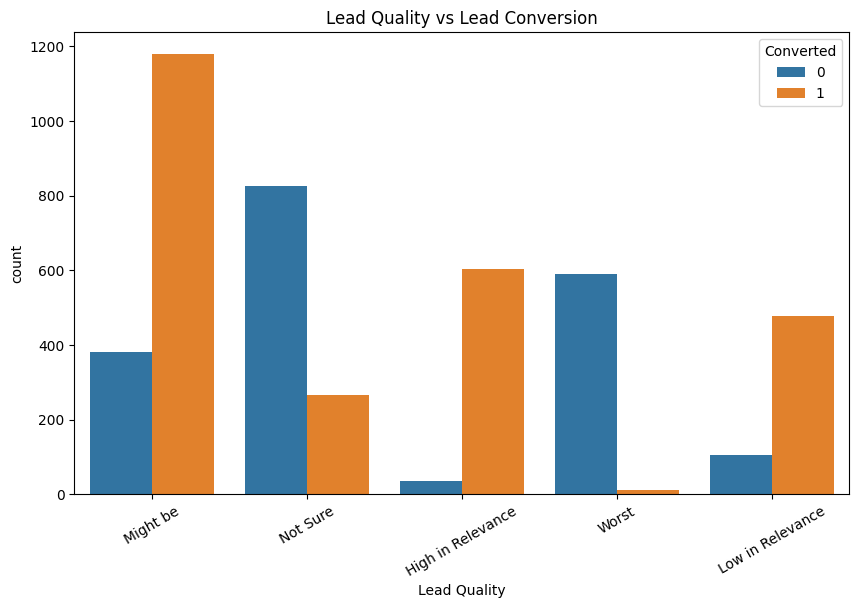

In [25]:
plt.figure(figsize=(10,6))

order = df['Lead Quality'].value_counts().index

sns.countplot(
    data=df,
    x='Lead Quality',
    hue='Converted',
    order=order
)

plt.xticks(rotation=30)
plt.title("Lead Quality vs Lead Conversion")

plt.show()

In [26]:
pd.crosstab(
    df['Lead Quality'],
    df['Converted'],
    normalize='index'
).round(2) * 100

Converted,0,1
Lead Quality,,
High in Relevance,5.0,95.0
Low in Relevance,18.0,82.0
Might be,24.0,76.0
Not Sure,76.0,24.0
Worst,98.0,2.0


### 📌 Observation

Compare conversion percentages across different Lead Quality levels.

### 💼 Business Insight

High-quality leads should receive immediate attention from the sales team, while low-quality leads may require nurturing campaigns.

## 8️⃣ Specialization Analysis

Specialization indicates the professional background of a lead.

Analyzing specialization helps understand which industries show greater interest in X Education's courses.

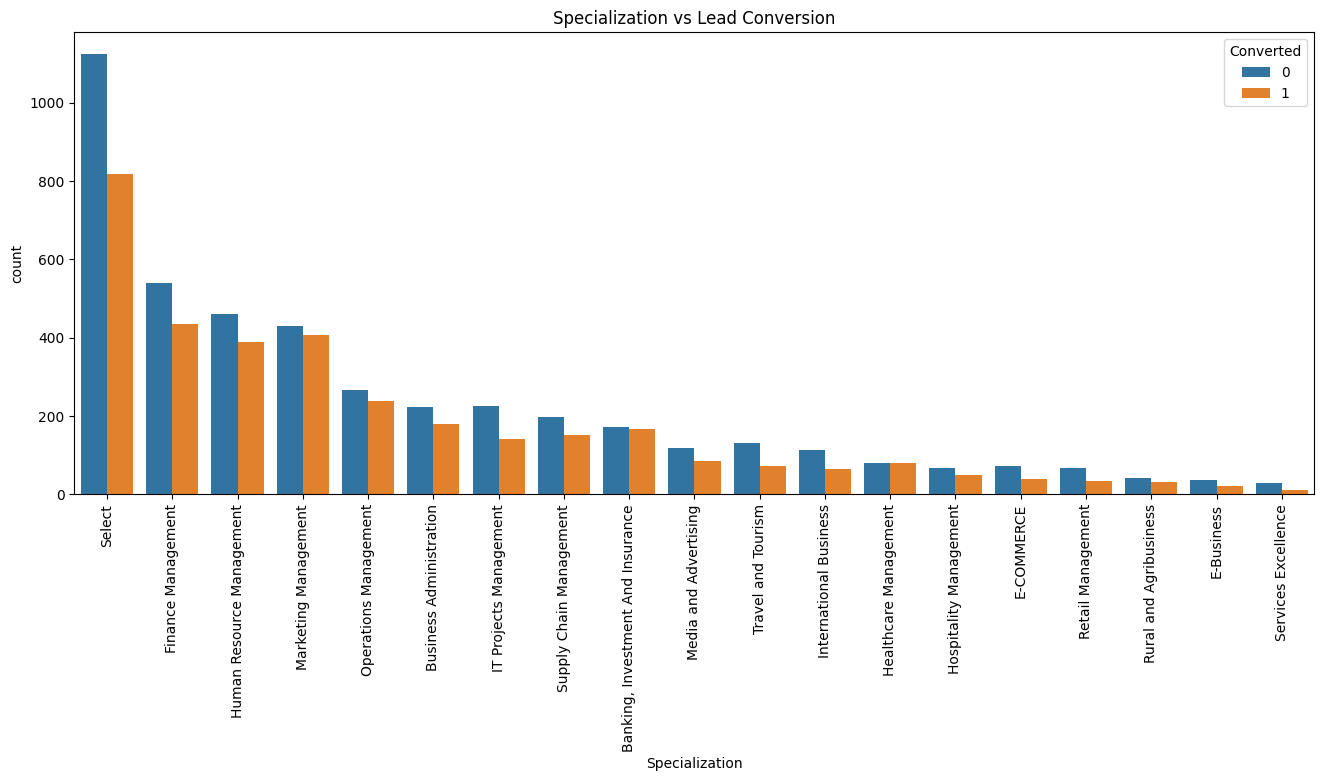

In [27]:
plt.figure(figsize=(16,6))

order = df['Specialization'].value_counts().index

sns.countplot(
    data=df,
    x='Specialization',
    hue='Converted',
    order=order
)

plt.xticks(rotation=90)
plt.title("Specialization vs Lead Conversion")

plt.show()

In [28]:
pd.crosstab(
    df['Specialization'],
    df['Converted'],
    normalize='index'
).round(2) * 100

Converted,0,1
Specialization,,
"Banking, Investment And Insurance",51.0,49.0
Business Administration,56.0,44.0
E-Business,63.0,37.0
E-COMMERCE,64.0,36.0
Finance Management,55.0,45.0
Healthcare Management,50.0,50.0
Hospitality Management,58.0,42.0
Human Resource Management,54.0,46.0
IT Projects Management,62.0,38.0


### 📌 Observation

Identify specializations with comparatively higher conversion rates.

### 💼 Business Insight

The marketing team can design specialization-specific campaigns to improve engagement and conversions.

## 9️⃣ Country Analysis

Understanding the geographical distribution of leads helps identify key markets and regions with strong conversion potential.

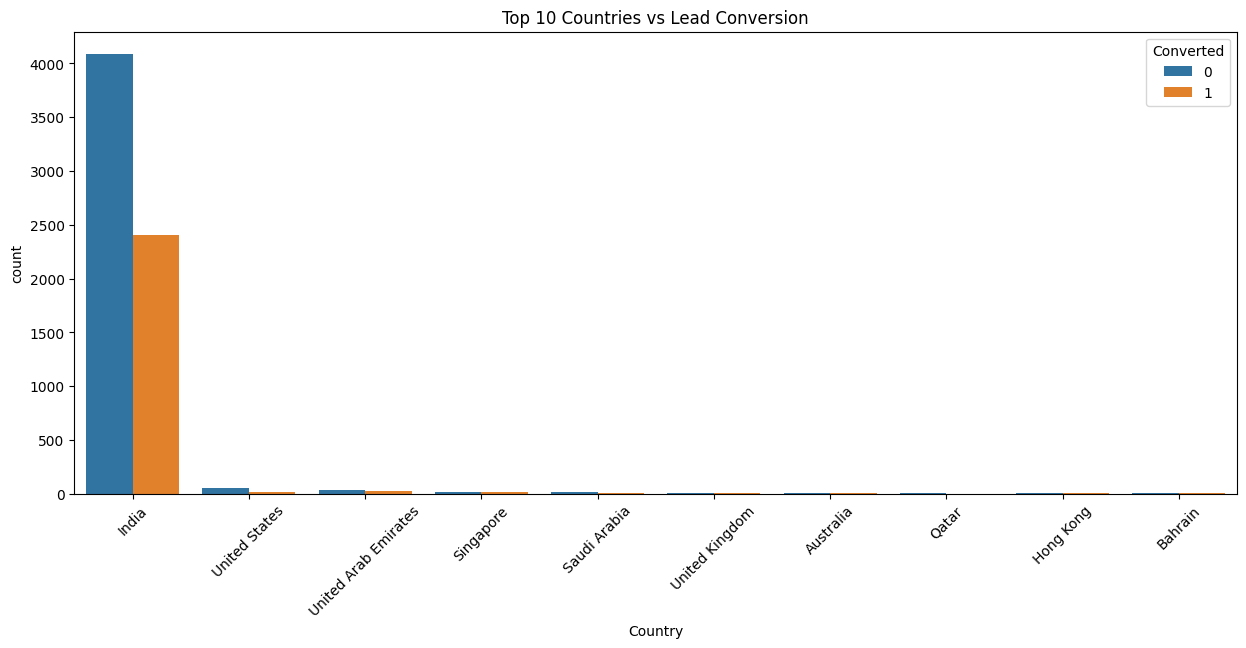

In [29]:
plt.figure(figsize=(15,6))

top_country = df['Country'].value_counts().head(10).index

sns.countplot(
    data=df[df['Country'].isin(top_country)],
    x='Country',
    hue='Converted',
    order=top_country
)

plt.xticks(rotation=45)
plt.title("Top 10 Countries vs Lead Conversion")

plt.show()

### 📌 Observation

Analyze the conversion behavior across the top countries.

### 💼 Business Insight

Countries with consistently higher conversion rates can become priority markets for future marketing campaigns.

## 🔟 Correlation Analysis

Correlation analysis helps identify relationships among numerical variables and detect potential multicollinearity.

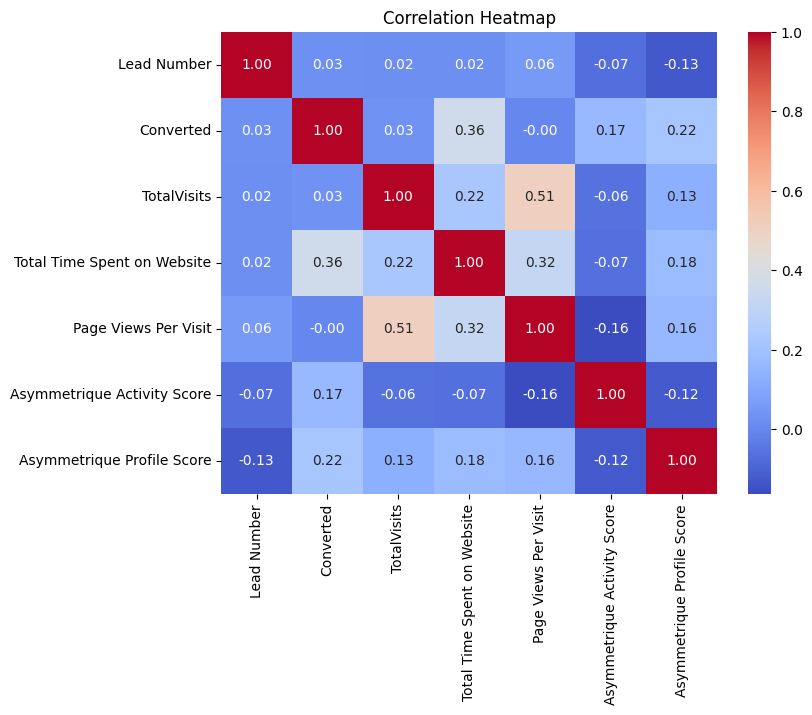

In [30]:
plt.figure(figsize=(8,6))

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## 📌 Key Findings from Exploratory Data Analysis

Based on the exploratory analysis, several factors appear to influence lead conversion:

- Website engagement plays a significant role in conversion.
- Certain lead sources consistently produce higher-quality leads.
- Recent customer activities provide valuable insights into purchase intent.
- Occupation and specialization influence conversion probability.
- Lead Quality is expected to be one of the strongest predictive features.
- Geographical distribution also impacts conversion trends.

These findings will guide the feature engineering and data preprocessing steps in the next phase.

# 📈 Univariate Analysis

Univariate Analysis focuses on understanding the distribution of individual numerical variables.

The objectives are:

- Understand feature distributions
- Detect skewness
- Identify potential outliers
- Support preprocessing decisions

In [31]:
num_cols
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Lead Number,9240.0,617188.435606,23405.995698,579533.0,596484.5,615479.0,637387.25,660737.0
Converted,9240.0,0.385390,0.486714,0.0,0.0,0.0,1.00,1.0
TotalVisits,9103.0,3.445238,4.854853,0.0,1.0,3.0,5.00,251.0
Total Time Spent on Website,9240.0,487.698268,548.021466,0.0,12.0,248.0,936.00,2272.0
Page Views Per Visit,9103.0,2.362820,2.161418,0.0,1.0,2.0,3.00,55.0
Asymmetrique Activity Score,5022.0,14.306252,1.386694,7.0,14.0,14.0,15.00,18.0
Asymmetrique Profile Score,5022.0,16.344883,1.811395,11.0,15.0,16.0,18.00,20.0


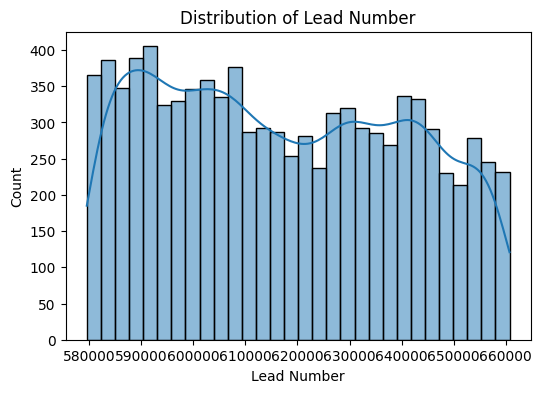

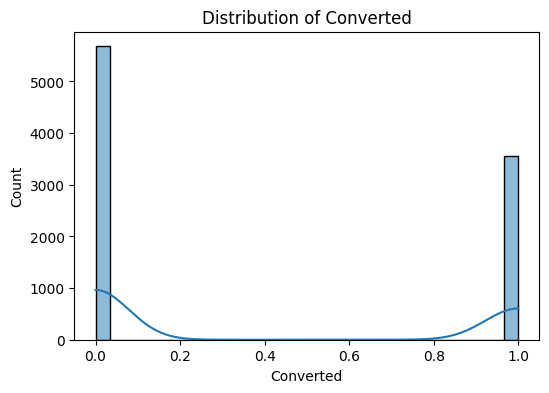

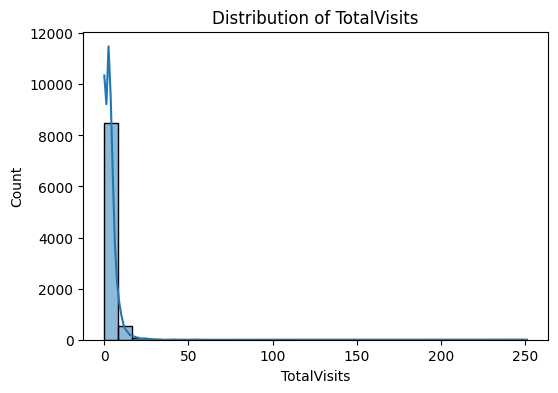

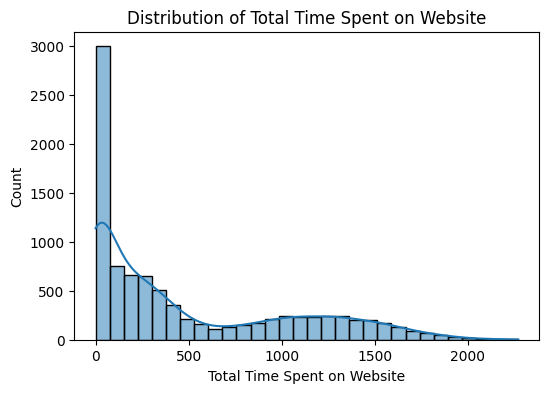

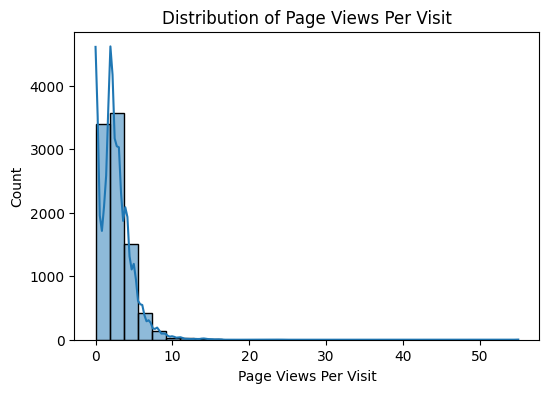

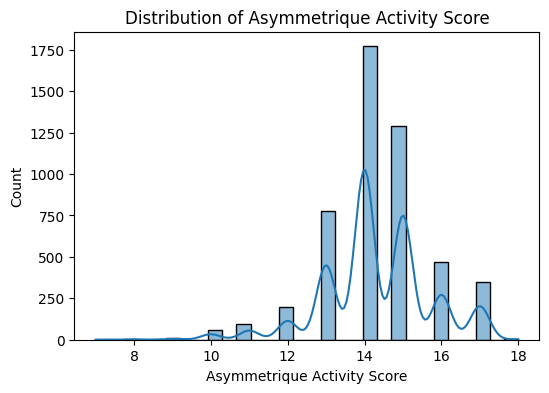

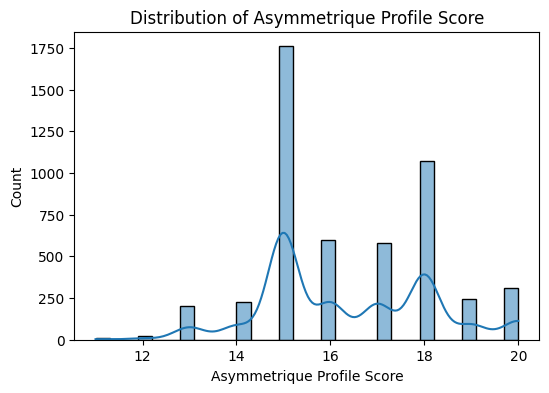

In [32]:
for col in num_cols:
    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {col}")

    plt.show()

### 📌 Observation

Observe whether the distributions are:

- Normally distributed
- Right-skewed
- Left-skewed

### 💼 Business Insight

Understanding feature distributions helps determine whether transformations or scaling techniques may be required before model training.

## Outlier Detection

Boxplots help identify extreme observations that may influence model performance.

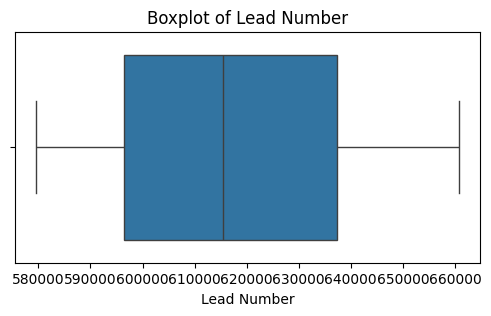

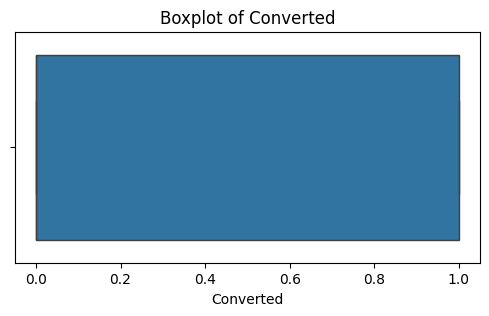

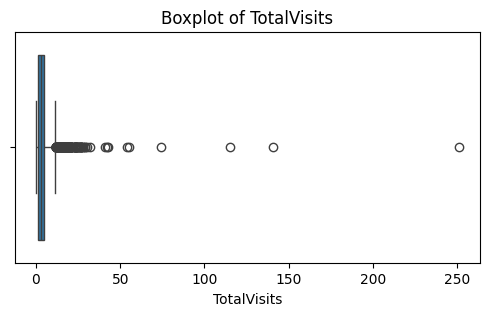

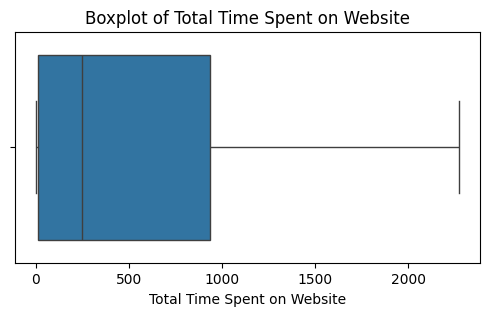

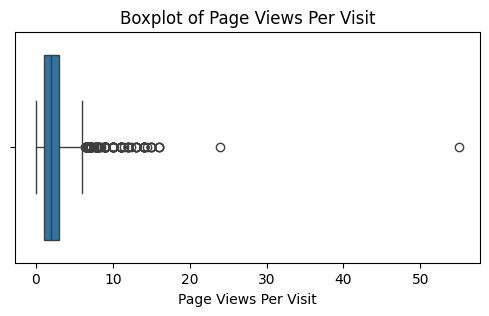

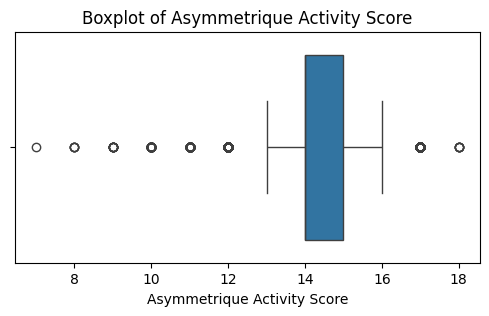

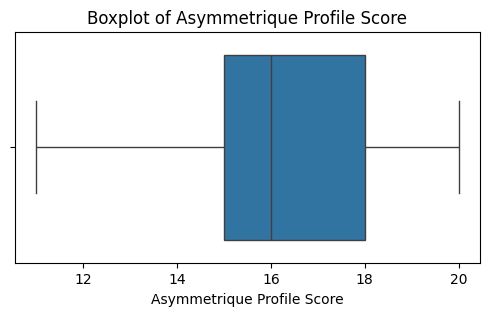

In [33]:
for col in num_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

### 📌 Observation

Identify numerical features containing significant outliers.

### 💼 Business Insight

Outliers may represent either abnormal customer behavior or valuable business cases. Therefore, they should be carefully evaluated before removal.

# 📑 Summary of Exploratory Data Analysis

- Lead conversion rate is relatively low.
- Website engagement strongly influences conversion.
- Certain lead sources generate higher-quality leads.
- Customer occupation and specialization affect conversion probability.
- Lead Quality appears to be a strong predictor.
- Several variables contain missing values requiring preprocessing.
- Numerical features exhibit varying distributions and some contain outliers.


# 🧹 Data Cleaning & Preprocessing

Real-world datasets often contain missing values, duplicate records, irrelevant features, and inconsistent data.

The objective of this section is to prepare the dataset for machine learning by:

- Removing irrelevant features
- Handling missing values
- Identifying redundant columns
- Treating inconsistent categorical values
- Preparing the dataset for feature engineering

In [34]:
feature_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": round(df.isnull().mean()*100,2),
    "Unique Values": df.nunique()
})
feature_summary

,Data Type,Missing Values,Missing %,Unique Values
Prospect ID,object,0,0.00,9240
Lead Number,int64,0,0.00,9240
Lead Origin,object,0,0.00,5
Lead Source,object,36,0.39,21
Do Not Email,object,0,0.00,2
Do Not Call,object,0,0.00,2
Converted,int64,0,0.00,2
TotalVisits,float64,137,1.48,41
Total Time Spent on Website,int64,0,0.00,1731
Page Views Per Visit,float64,137,1.48,114


In [35]:
#Checking Duplicate records
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [36]:
# 🔍 Checking Constant Features
constant_cols = []

for col in df.columns:
    if df[col].nunique() == 1:
        constant_cols.append(col)

print(constant_cols)

['Magazine', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'I agree to pay the amount through cheque']


### 📌 Observation

The above features contain only a single unique value throughout the dataset.

Since they do not contribute any predictive information, they will be removed in the preprocessing stage.

In [37]:
# 🔍 Identifying Identifier Columns
identifier_cols = [
    "Prospect ID",
    "Lead Number"
]
identifier_cols

['Prospect ID', 'Lead Number']

### 📌 Observation

`Prospect ID` and `Lead Number` are unique identifiers assigned to each lead.

These variables do not influence customer behavior or conversion probability and may introduce unnecessary noise into the model.

Therefore, they will be removed.

In [38]:
df.drop(columns=identifier_cols, inplace=True)

print(df.shape)

(9240, 35)


In [39]:
df.drop(columns=constant_cols, inplace=True)

print(df.shape)

(9240, 30)


# 📊 Missing Value Treatment Strategy

Not all missing values should be treated in the same way.

Different strategies will be adopted based on:

- Percentage of missing values
- Business importance
- Nature of the feature

In [40]:
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": round(df.isnull().mean()*100,2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage
Lead Quality,4767,51.59
Asymmetrique Profile Score,4218,45.65
Asymmetrique Activity Index,4218,45.65
Asymmetrique Activity Score,4218,45.65
Asymmetrique Profile Index,4218,45.65
Tags,3353,36.29
What matters most to you in choosing a course,2709,29.32
Lead Profile,2709,29.32
What is your current occupation,2690,29.11
Country,2461,26.63


## 📝 Planning the Missing Value Treatment

Instead of applying a single strategy to all features, each feature will be analyzed individually.

Different treatments such as dropping, imputing with the mode, replacing with "Unknown", or retaining the feature will be applied depending on its business significance and data quality.

## Step 1: Removing Features with Extremely High Missing Values

Features with more than **35% missing values** provide very limited information and can negatively affect model performance.

Such features will be removed unless they have strong business significance.

In [41]:
high_missing_cols = missing_df[
    missing_df["Missing Percentage"] > 35
].index.tolist()

high_missing_cols

['Tags',
 'Lead Quality',
 'Asymmetrique Activity Index',
 'Asymmetrique Profile Index',
 'Asymmetrique Activity Score',
 'Asymmetrique Profile Score']

### 📌 Observation

**Lead Quality** has been retained despite its missing values because it represents the salesperson's assessment of the lead and is expected to be a valuable predictor of conversion.

In [42]:
drop_cols = [
    'Tags',
    'Asymmetrique Activity Index',
    'Asymmetrique Profile Index',
    'Asymmetrique Activity Score',
    'Asymmetrique Profile Score'
]

df.drop(columns=drop_cols, inplace=True)

print(df.shape)

(9240, 25)


In [43]:
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": round(df.isnull().mean()*100,2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage
Lead Quality,4767,51.59
What matters most to you in choosing a course,2709,29.32
Lead Profile,2709,29.32
What is your current occupation,2690,29.11
Country,2461,26.63
How did you hear about X Education,2207,23.89
Specialization,1438,15.56
City,1420,15.37
Page Views Per Visit,137,1.48
TotalVisits,137,1.48


## 🎯 Treating the 'Lead Quality' Feature

Although the `Lead Quality` feature contains a high percentage of missing values, it represents the salesperson's assessment of a lead and is expected to be highly informative.

Instead of dropping the feature, the missing values will be replaced with **"Unknown"** to preserve potentially useful information while indicating that the quality assessment was unavailable.

In [44]:
df["Lead Quality"].fillna("Unknown", inplace=True)
df["Lead Quality"].isnull().sum()

np.int64(0)

## 🎯 Treating 'Lead Profile'

Missing values in `Lead Profile` indicate that the customer's profile was not assigned.

To preserve this information, missing values will be replaced with **"Unknown"**.

In [45]:
df["Lead Profile"].fillna("Unknown", inplace=True)

## 🎯 Treating 'What is your current occupation'

A missing occupation does not necessarily mean the customer has no occupation; it simply indicates that the information was not provided.

Therefore, missing values will be replaced with **"Unknown"**.

In [46]:
df["What is your current occupation"].fillna("Unknown", inplace=True)

## 🎯 Treating 'Country'

Country is an important geographical feature.

Replacing missing values with **"Unknown"** preserves the information that the country was not available without introducing bias.

In [47]:
df["Country"].fillna("Unknown", inplace=True)

## 🎯 Treating 'How did you hear about X Education'

Missing values indicate that the lead source information was unavailable.

These values will be replaced with **"Unknown"**.

In [48]:
df["How did you hear about X Education"].fillna("Unknown", inplace=True)

## 🎯 Treating 'Specialization'

Many users did not specify their specialization while filling out the form.

Instead of removing these records, missing values will be replaced with **"Unknown"**.

In [49]:
df["Specialization"].fillna("Unknown", inplace=True)

## 🎯 Treating 'City'

City information is missing for some leads.

Missing values will be replaced with **"Unknown"** to retain all observations.

In [50]:
df["City"].fillna("Unknown", inplace=True)

## 🎯 Treating Numerical Features with Missing Values

The numerical features `TotalVisits` and `Page Views Per Visit` contain only a small percentage of missing values (less than 2%).

To avoid losing valuable observations, the missing values will be imputed using the **median**, which is robust to outliers.

In [51]:
df["TotalVisits"].fillna(
    df["TotalVisits"].median(),
    inplace=True
)

df["Page Views Per Visit"].fillna(
    df["Page Views Per Visit"].median(),
    inplace=True
)

## 🎯 Treating Categorical Features with Missing Values

The features `Last Activity` and `Lead Source` contain only a few missing values.

Since these are categorical variables, the missing values will be replaced with the **most frequently occurring category (Mode)**.

In [52]:
df["Last Activity"].fillna(
    df["Last Activity"].mode()[0],
    inplace=True
)

df["Lead Source"].fillna(
    df["Lead Source"].mode()[0],
    inplace=True
)

> **Note:**  
> The missing values in `Last Activity` and `Lead Source` were imputed **before the train-test split** using the mode of the complete dataset. Since these columns contain a very small percentage of missing values, the impact on model performance is expected to be minimal.  
>
> In a production-grade machine learning pipeline, this preprocessing step would ideally be performed **after the train-test split** (or within a preprocessing pipeline using `SimpleImputer`) to completely avoid potential data leakage.

## 🎯 Treating 'What matters most to you in choosing a course'

The feature is highly imbalanced, with almost all observations belonging to **"Better Career Prospects"**.

This feature has very low variability and is unlikely to contribute meaningful predictive information.

Therefore, this feature will be removed from the dataset.

In [53]:
df.drop(
    columns=["What matters most to you in choosing a course"],
    inplace=True
)
print(df.shape)

(9240, 24)


## ✅ Verifying Missing Value Treatment

After applying the preprocessing steps, we verify that all missing values have been successfully handled.

In [54]:
df.isnull().sum().sort_values(ascending=False)

,0
Lead Origin,0
Lead Source,0
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,0
Total Time Spent on Website,0
Page Views Per Visit,0
Last Activity,0
Country,0


## 🎯 Handling Placeholder Values ('Select')

Some categorical variables contain the value **"Select"**, which represents a missing response rather than a valid category.

To preserve these records while accurately representing missing information, all occurrences of **"Select"** will be replaced with **"Unknown"**.

In [55]:
select_columns = []

for col in df.select_dtypes(include="object").columns:
    if "Select" in df[col].astype(str).unique():
        select_columns.append(col)

print(select_columns)

['Specialization', 'How did you hear about X Education', 'Lead Profile', 'City']


In [56]:
for col in select_columns:
    df[col] = df[col].replace("Select", "Unknown")

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Lead Origin                             9240 non-null   object 
 1   Lead Source                             9240 non-null   object 
 2   Do Not Email                            9240 non-null   object 
 3   Do Not Call                             9240 non-null   object 
 4   Converted                               9240 non-null   int64  
 5   TotalVisits                             9240 non-null   float64
 6   Total Time Spent on Website             9240 non-null   int64  
 7   Page Views Per Visit                    9240 non-null   float64
 8   Last Activity                           9240 non-null   object 
 9   Country                                 9240 non-null   object 
 10  Specialization                          9240 non-null   obje

# 🔍 Identifying Low Variance Features

Some categorical features may contain one dominant category and very few occurrences of the other category.

Such features contribute very little to the predictive performance of the model and may be removed after analysis.

In [58]:
low_variance_cols = [
    "Search",
    "Newspaper Article",
    "X Education Forums",
    "Newspaper",
    "Digital Advertisement",
    "Through Recommendations",
    "Do Not Call"
]

for col in low_variance_cols:
    print(f"\n{'='*50}")
    print(col)
    print(df[col].value_counts())


Search
Search
No     9226
Yes      14
Name: count, dtype: int64

Newspaper Article
Newspaper Article
No     9238
Yes       2
Name: count, dtype: int64

X Education Forums
X Education Forums
No     9239
Yes       1
Name: count, dtype: int64

Newspaper
Newspaper
No     9239
Yes       1
Name: count, dtype: int64

Digital Advertisement
Digital Advertisement
No     9236
Yes       4
Name: count, dtype: int64

Through Recommendations
Through Recommendations
No     9233
Yes       7
Name: count, dtype: int64

Do Not Call
Do Not Call
No     9238
Yes       2
Name: count, dtype: int64


In [59]:
low_variance_cols = [
    "Search",
    "Newspaper Article",
    "X Education Forums",
    "Newspaper",
    "Digital Advertisement",
    "Through Recommendations",
    "Do Not Call"
]

df.drop(columns=low_variance_cols, inplace=True)

print(df.shape)

(9240, 17)


### 📌 Observation

The removed features contained overwhelmingly one category ("No") with only a handful of positive observations.

### 💼 Business Insight

Such low-variance features contribute little to predictive performance and may increase model complexity without improving accuracy.

# 🤖 Machine Learning Pipeline

The cleaned dataset is now ready for machine learning.

In this phase, we will:

- Separate features and target variable
- Identify numerical and categorical features
- Apply appropriate preprocessing techniques
- Prepare the data for model training

In [60]:
X = df.drop("Converted", axis=1)
y = df["Converted"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (9240, 16)
Target Shape : (9240,)


## 🎯 Identifying Feature Types

Machine learning models require numerical input.

Therefore, we first identify:

- Numerical Features
- Categorical Features

Different preprocessing techniques will be applied to each type.

In [61]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

Categorical Features:
['Lead Origin', 'Lead Source', 'Do Not Email', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'Lead Quality', 'Lead Profile', 'City', 'A free copy of Mastering The Interview', 'Last Notable Activity']


## ⚙️ Building the Preprocessing Pipeline

The preprocessing pipeline performs:

### Numerical Features
- Median Imputation (already completed)
- Standard Scaling

### Categorical Features
- One-Hot Encoding

In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ( "num", StandardScaler(), numerical_features ),
        ( "cat", OneHotEncoder(handle_unknown="ignore"), categorical_features )
    ]
)


## ✂️ Splitting the Dataset

The dataset is divided into training and testing subsets.

- Training Set: 80%
- Testing Set: 20%

The training set is used to build the model, while the testing set is used to evaluate its performance on unseen data.

In [63]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7392, 16)
(1848, 16)


**Let's Remember Our Initial Target:**

"The CEO, in particular, has given a ballpark of the target lead conversion rate to be around 80."

So, with this in mind, we can select our most important performance measure.
In this case, we want to ensure that a high percentage of predicted leads convert to a customer, which means we're looking for a high precision score.

**Does that mean we won't care about potential leads not detected (Low recall)?**

Not at all. If we tune our models to optimize only for precision, we might be very accurate in their positive predictions but miss many actual positive cases. This translates into leaving money on the table—potential customers that won't convert.

# 🚀 Model 1: Logistic Regression

Logistic Regression is a simple yet powerful classification algorithm commonly used as a baseline model for binary classification problems.

It estimates the probability of a lead getting converted based on the input features.

Accuracy : 0.8306277056277056
Precision: 0.7920937042459737
Recall   : 0.7598314606741573
F1 Score : 0.7756272401433691
ROC AUC  : 0.9055805161022313

=== Overfitting Diagnostics ===
Train ROC-AUC   : 0.9364
Test ROC-AUC    : 0.9056
Overfitting Gap : 0.0308


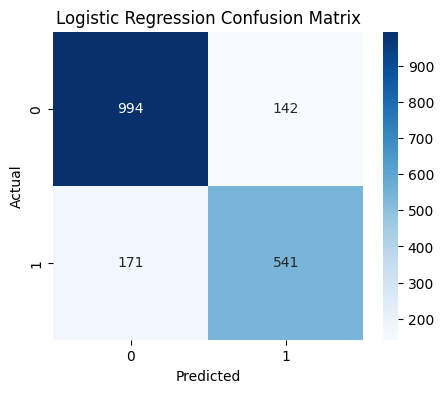

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1136
           1       0.79      0.76      0.78       712

    accuracy                           0.83      1848
   macro avg       0.82      0.82      0.82      1848
weighted avg       0.83      0.83      0.83      1848



In [75]:
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)

y_pred_lr = logistic_pipeline.predict(X_test)
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:,1]

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC AUC  :", lr_auc)

# ==========================================
# Overfitting Diagnostics
# ==========================================
y_prob_lr_train = logistic_pipeline.predict_proba(X_train)[:, 1]
lr_auc_train = roc_auc_score(y_train, y_prob_lr_train)
lr_overfitting_gap = lr_auc_train - lr_auc

print("\n=== Overfitting Diagnostics ===")
print(f"Train ROC-AUC   : {lr_auc_train:.4f}")
print(f"Test ROC-AUC    : {lr_auc:.4f}")
print(f"Overfitting Gap : {lr_overfitting_gap:.4f}")


#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


#Classification Report
print(classification_report(y_test, y_pred_lr))

# 🌳 Model 2: Random Forest

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions.

It generally captures nonlinear relationships better than Logistic Regression.

In [81]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_estimators=200
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

rf_accuracy = accuracy_score(y_test,y_pred_rf)
rf_precision = precision_score(y_test,y_pred_rf)
rf_recall = recall_score(y_test,y_pred_rf)
rf_f1 = f1_score(y_test,y_pred_rf)
rf_auc = roc_auc_score(y_test,y_prob_rf)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC AUC  :", rf_auc)


# Evaluate the final model back onto the training set
train_probs_rfnn =rf_pipeline.predict_proba(X_train)[:, 1]
train_aucc = roc_auc_score(y_train, train_probs_rfnn)

# Calculate the metric gap
overfitting_gap = train_aucc - rf_auc

print("\n=== Overfitting Diagnostics ===")
print(f"Train ROC-AUC   : {train_aucc:.4f}")
print(f"Test ROC-AUC    : {rf_auc:.4f}")
print(f"Overfitting Gap : {overfitting_gap:.4f}")


Accuracy : 0.8463203463203464
Precision: 0.8165680473372781
Recall   : 0.7752808988764045
F1 Score : 0.7953890489913544
ROC AUC  : 0.9144259871023898

=== Overfitting Diagnostics ===
Train ROC-AUC   : 0.9959
Test ROC-AUC    : 0.9144
Overfitting Gap : 0.0814


To maximize model generalisation and fine-tune performance, RandomizedSearchCV was implemented alongside a 5-fold StratifiedKFold cross-validation strategy.

In [80]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ==========================================
# Random Forest Pipeline
# ==========================================

rf_engine_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("rf_node", RandomForestClassifier(random_state=42))
])
# ==========================================
# Hyperparameter Grid
# ==========================================

rf_search_space = {
    "rf_node__n_estimators":[100, 200, 300, 500],
    "rf_node__max_depth": [None, 10, 20, 30],
    "rf_node__min_samples_split": [2, 5, 10],
    "rf_node__min_samples_leaf": [1, 2, 4],
    "rf_node__max_features": ["sqrt", "log2"]
}

# ==========================================
# Explicit Stratified Cross-Validation
# ==========================================

strat_fold_config = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ==========================================
# Hyperparameter Tuning
# ==========================================

rf_tuning_engine = RandomizedSearchCV(
    estimator=rf_engine_pipe,
    param_distributions=rf_search_space,
    n_iter=20,
    scoring="roc_auc",
    cv=strat_fold_config,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rf_tuning_engine.fit(X_train, y_train)

# ==========================================
# Best Model
# ==========================================

optimized_rf_model = rf_tuning_engine.best_estimator_

print("Best Parameters:")
print(rf_tuning_engine.best_params_)

print("\nBest Cross Validation ROC-AUC:")
print(round(rf_tuning_engine.best_score_, 4))

# ==========================================
# Predictions
# ==========================================

holdout_preds_rf = optimized_rf_model.predict(X_test)
holdout_probs_rf = optimized_rf_model.predict_proba(X_test)[:, 1]

# ==========================================
# Evaluation
# ==========================================

rf_score_accuracy = accuracy_score(y_test, holdout_preds_rf)
rf_score_precision = precision_score(y_test, holdout_preds_rf)
rf_score_recall = recall_score(y_test, holdout_preds_rf)
rf_score_f1 = f1_score(y_test, holdout_preds_rf)
rf_score_auc = roc_auc_score(y_test, holdout_probs_rf)

print("\nTest Set Performance")
print("--------------------")
print(f"Accuracy : {rf_score_accuracy:.4f}")
print(f"Precision: {rf_score_precision:.4f}")
print(f"Recall   : {rf_score_recall:.4f}")
print(f"F1 Score : {rf_score_f1:.4f}")
print(f"ROC AUC  : {rf_score_auc:.4f}")

# ==========================================
# Overfitting Gap Analysis
# ==========================================

train_probs_rf = optimized_rf_model.predict_proba(X_train)[:, 1]
rf_train_auc = roc_auc_score(y_train, train_probs_rf)
rf_overfit_gap = rf_train_auc - rf_score_auc

print("\n=== Overfitting Diagnostics ===")
print(f"Train ROC-AUC   : {rf_train_auc:.4f}")
print(f"Test ROC-AUC    : {rf_score_auc:.4f}")
print(f"Overfitting Gap : {rf_overfit_gap:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'rf_node__n_estimators': 200, 'rf_node__min_samples_split': 10, 'rf_node__min_samples_leaf': 2, 'rf_node__max_features': 'sqrt', 'rf_node__max_depth': 30}

Best Cross Validation ROC-AUC:
0.939

Test Set Performance
--------------------
Accuracy : 0.8474
Precision: 0.8180
Recall   : 0.7767
F1 Score : 0.7968
ROC AUC  : 0.9215

=== Overfitting Diagnostics ===
Train ROC-AUC   : 0.9712
Test ROC-AUC    : 0.9215
Overfitting Gap : 0.0497


# ⚡ Model 3: XGBoost

XGBoost is a gradient boosting algorithm known for its high predictive performance on structured datasets.

It builds trees sequentially, correcting previous errors to improve overall accuracy.

In [74]:
# ==========================================
# New Pipeline Definition
# ==========================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Swapped variable names to unique alternative names
xgb_core_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb_node", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

# ==========================================
# Tuning Space (Prefix matches 'xgb_node__')
# ==========================================

xgb_hyper_space = {
    'xgb_node__n_estimators':[100, 200, 300, 500],
    'xgb_node__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb_node__max_depth':[3, 5, 7, 10],
    'xgb_node__min_child_weight':[1, 3, 5, 7],
    'xgb_node__subsample': [0.7, 0.8, 0.9],
    'xgb_node__colsample_bytree': [0.7, 0.8, 0.9],
    'xgb_node__gamma': [0, 0.1, 0.2]
}

# ==========================================
# Hyperparameter Tuning Execution
# ==========================================
stratified_cv_splits = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


xgb_tuning_search = RandomizedSearchCV(
    estimator=xgb_core_pipe,
    param_distributions=xgb_hyper_space,
    n_iter=20,
    scoring="roc_auc",
    cv=stratified_cv_splits,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# Fit randomized search to training data
xgb_tuning_search.fit(X_train, y_train)
optimized_xgb_model = xgb_tuning_search.best_estimator_

# ==========================================
# Test Set Evaluation
# ==========================================

final_preds_xgb = optimized_xgb_model.predict(X_test)
final_probs_xgb = optimized_xgb_model.predict_proba(X_test)[:, 1]

metric_accuracy = accuracy_score(y_test, final_preds_xgb)
metric_precision = precision_score(y_test, final_preds_xgb)
metric_recall = recall_score(y_test, final_preds_xgb)
metric_f1 = f1_score(y_test, final_preds_xgb)
metric_auc = roc_auc_score(y_test, final_probs_xgb)

print("=== Optimized Test Performance ===")
print("Accuracy :", round(metric_accuracy, 4))
print("Precision:", round(metric_precision, 4))
print("Recall   :", round(metric_recall, 4))
print("F1 Score :", round(metric_f1, 4))
print("ROC AUC  :", round(metric_auc, 4))

# ==========================================
# Overfitting Gap Analysis
# ==========================================

# Evaluate the final model back onto the training set
train_probs_xgb = optimized_xgb_model.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, train_probs_xgb)

# Calculate the metric gap
overfitting_gap = train_auc - metric_auc

print("\n=== Overfitting Diagnostics ===")
print(f"Train ROC-AUC   : {train_auc:.4f}")
print(f"Test ROC-AUC    : {metric_auc:.4f}")
print(f"Overfitting Gap : {overfitting_gap:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
=== Optimized Test Performance ===
Accuracy : 0.8512
Precision: 0.8237
Recall   : 0.7809
F1 Score : 0.8017
ROC AUC  : 0.9235

=== Overfitting Diagnostics ===
Train ROC-AUC   : 0.9561
Test ROC-AUC    : 0.9235
Overfitting Gap : 0.0327


## ⚡ Model 4: Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised Machine Learning algorithm used for classification tasks. It works by finding the optimal hyperplane that maximizes the margin between different classes. SVM is particularly effective in high-dimensional spaces and can model non-linear decision boundaries using different kernel functions.

The model is evaluated using:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

In [72]:
from sklearn.svm import SVC
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        kernel="rbf",
        C=1,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

svm_pipeline.fit(X_train, y_train)
train_probs=svm_pipeline.predict_proba(X_train)[:,1]
y_pred_svm = svm_pipeline.predict(X_test)
y_prob_svm = svm_pipeline.predict_proba(X_test)[:,1]
# ==========================================
# Evaluation
# ==========================================

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_auc = roc_auc_score(y_test, y_prob_svm)

print("\nTest Set Performance")
print("-----------------------------")
print("Accuracy :", round(svm_accuracy,4))
print("Precision:", round(svm_precision,4))
print("Recall   :", round(svm_recall,4))
print("F1 Score :", round(svm_f1,4))
print("ROC AUC  :", round(svm_auc,4))
print(f"Overfitting Gap: {abs(roc_auc_score(y_train, train_probs) - roc_auc_score(y_test, y_prob_svm)):.4f}")


Test Set Performance
-----------------------------
Accuracy : 0.8523
Precision: 0.8321
Recall   : 0.7725
F1 Score : 0.8012
ROC AUC  : 0.9132
Overfitting Gap: 0.0369


## 💡Model 5: LightGBM Classification

LightGBM (Light Gradient Boosting Machine) is a gradient boosting framework developed by Microsoft. It is specifically designed for high-performance machine learning on structured/tabular datasets.

Unlike traditional Gradient Boosting, LightGBM grows trees **leaf-wise**, allowing it to achieve higher accuracy while maintaining faster training speed.

In this project, **RandomizedSearchCV** is used to efficiently search the hyperparameter space because LightGBM has several important tuning parameters.

The tuned model is evaluated using:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

In [67]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier


#  DEFINE BASE PIPELINE & ANTI-OVERFITTING GRID ---
pipeline_lgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(verbose=-1, random_state=42, n_jobs=-1))
])

lgb_grid = {
    'model__n_estimators':[100,200,300,500],
    'model__learning_rate': [0.01, 0.02, 0.05],
    'model__max_depth':[-1,5,10,15],              # Limits tree split length
    'model__num_leaves':[31,50,70,100],            # Restricted leaves to combat overfitting
    'model__reg_lambda': [3.0, 5.0, 10.0],       # L2 regularization
    'model__reg_alpha': [0.5, 1.0, 2.0],         # L1 regularization
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9]
}

# RUN STRATIFIED RANDOMIZED SEARCH ---
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_search = RandomizedSearchCV(
    estimator=pipeline_lgb,
    param_distributions=lgb_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1
)

print("Tuning LightGBM...")
lgb_search.fit(X_train, y_train)

# --- 4. EVALUATE OVERFITTING AND PERFORMANCE ---
best_lgb_pipeline = lgb_search.best_estimator_

print(f"\nBest Parameters: {lgb_search.best_params_}")

# Check for overfitting gap
train_probs = best_lgb_pipeline.predict_proba(X_train)[:, 1]
test_probs = best_lgb_pipeline.predict_proba(X_test)[:, 1]
test_preds = best_lgb_pipeline.predict(X_test)

lgb_accuracy = accuracy_score(y_test,test_preds)
lgb_precision = precision_score(y_test,test_preds)
lgb_recall = recall_score(y_test,test_preds)
lgb_f1 = f1_score(y_test,test_preds)
lgb_auc = roc_auc_score(y_test,test_probs)

print("\nTest Set Performance")
print("-----------------------------")

print("Accuracy :", round(lgb_accuracy,4))
print("Precision:", round(lgb_precision,4))
print("Recall   :", round(lgb_recall,4))
print("F1 Score :", round(lgb_f1,4))
print("ROC AUC  :", round(lgb_auc,4))

print(f"Train ROC-AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, test_probs):.4f}")
print(f"Overfitting Gap: {abs(roc_auc_score(y_train, train_probs) - roc_auc_score(y_test, test_probs)):.4f}")

Tuning LightGBM...

Best Parameters: {'model__subsample': 0.8, 'model__reg_lambda': 10.0, 'model__reg_alpha': 0.5, 'model__num_leaves': 50, 'model__n_estimators': 500, 'model__max_depth': -1, 'model__learning_rate': 0.02, 'model__colsample_bytree': 0.8}

Test Set Performance
-----------------------------
Accuracy : 0.849
Precision: 0.8115
Recall   : 0.7921
F1 Score : 0.8017
ROC AUC  : 0.922
Train ROC-AUC: 0.9661
Test ROC-AUC: 0.9220
Overfitting Gap: 0.0441


# 📈 Model Comparison

To identify the best-performing model, we compare all three models using standard evaluation metrics.

In [86]:
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","Tuned random forest","XGBoost","SVM","LightGBM"],
    "Accuracy":[lr_accuracy,rf_accuracy,rf_score_accuracy,metric_accuracy,svm_accuracy,lgb_accuracy],
    "Precision":[lr_precision,rf_precision,rf_score_precision,metric_precision,svm_precision,lgb_precision],
    "Recall":[lr_recall,rf_recall,rf_score_recall,metric_recall,svm_recall,lgb_recall],
    "F1 Score":[lr_f1,rf_f1,rf_score_f1,metric_f1,svm_f1,lgb_f1],
    "ROC AUC":[lr_auc,rf_auc,rf_score_auc,metric_auc,svm_auc,lgb_auc]
})

comparison.sort_values(
    by="ROC AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,XGBoost,0.851190,0.823704,0.780899,0.801730,0.923462
5,LightGBM,0.849026,0.811511,0.792135,0.801706,0.921989
2,Tuned random forest,0.847403,0.818047,0.776685,0.796830,0.921471
1,Random Forest,0.846320,0.816568,0.775281,0.795389,0.914426
4,SVM,0.852273,0.832073,0.772472,0.801165,0.913183
0,Logistic Regression,0.830628,0.792094,0.759831,0.775627,0.905581


# 🏆 Best Model Selection

Since the primary business objective is to help the sales team focus on leads that are most likely to convert, **Precision** is considered an important evaluation metric. A higher precision ensures that when the model predicts a lead as likely to convert, the prediction is more reliable, reducing time and resources spent on low-quality leads.

At the same time, **Recall** cannot be ignored because failing to identify genuine potential customers would result in missed business opportunities.

Therefore, instead of optimizing only Precision or only Recall, the **F1-Score** was used to evaluate the balance between the two metrics. Additionally, **ROC-AUC** was considered because the project aims to rank leads according to their probability of conversion, making the model's ranking ability equally important.

After comparing all the models, **XGBoost** was selected as the final deployment model because it achieved the best overall performance across the evaluation metrics:

- **ROC-AUC:** **92.35%** (Highest)
- **F1-Score:** **80.17%** (Highest)
- **Accuracy:** **85.12%** (Very close to the highest)
- **Precision:** **82.37%**
- **Recall:** **78.09%**

Although **SVM** achieved a slightly higher Accuracy (85.23%) and Precision (83.21%), the improvement was marginal, while its ROC-AUC was significantly lower than XGBoost. Similarly, **LightGBM** achieved the highest Recall but slightly lower Accuracy, Precision, and ROC-AUC.

Considering the overall business objective of accurately ranking high-potential leads while maintaining a strong balance between Precision, Recall, F1-Score, and ROC-AUC, **XGBoost provided the best overall performance** and was therefore selected as the final model for deployment in the Lead Scoring Dashboard.

In [87]:
import joblib

best_model = optimized_xgb_model

model_path = "/content/drive/MyDrive/Celebal_Final_Project/models/lead_scoring_model.pkl"

joblib.dump(best_model, model_path)

print(f"Model saved successfully at:\n{model_path}")

Model saved successfully at:
/content/drive/MyDrive/Celebal_Final_Project/models/lead_scoring_model.pkl


# 🎯 Generating Lead Scores

The model predicts the probability of conversion for each lead.

This probability is converted into a **Lead Score (0–100)**, where:

- 80–100 → Hot Lead
- 50–79 → Warm Lead
- 0–49 → Cold Lead

In [88]:
best_model.fit(X_train, y_train)

# 2. Now you can safely generate your probabilities and scores on your data
lead_probability = best_model.predict_proba(X)[:, 1]
df["Lead Score"] = (lead_probability * 100).round(2)
df[["Lead Score"]].head()


,Lead Score
0,35.150002
1,33.299999
2,91.879997
3,5.430000
4,68.120003


# 🔥 Lead Segmentation

Based on the Lead Score, each lead is categorized into one of three business-friendly segments:

- **Hot Lead:** High probability of conversion
- **Warm Lead:** Moderate probability of conversion
- **Cold Lead:** Low probability of conversion

In [89]:
def categorize(score):
    if score >= 80:
        return "Hot Lead"
    elif score >= 50:
        return "Warm Lead"
    else:
        return "Cold Lead"

df["Lead Category"] = df["Lead Score"].apply(categorize)
df["Lead Category"].value_counts()

,count
Lead Category,
Cold Lead,5891
Hot Lead,2284
Warm Lead,1065


In [90]:
df.sort_values(
    by="Lead Score",
    ascending=False
).head(10)

,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,Lead Quality,Lead Profile,City,A free copy of Mastering The Interview,Last Notable Activity,Lead Score,Lead Category
4935,API,Google,No,1,6.0,1094,2.00,SMS Sent,India,Marketing Management,Unknown,Working Professional,Might be,Potential Lead,Unknown,No,SMS Sent,98.589996,Hot Lead
3078,Lead Add Form,Reference,No,1,0.0,0,0.00,SMS Sent,Unknown,Human Resource Management,Unknown,Working Professional,High in Relevance,Potential Lead,Unknown,No,SMS Sent,98.550003,Hot Lead
4955,API,Google,No,1,9.0,1416,1.80,SMS Sent,India,Human Resource Management,Online Search,Working Professional,Might be,Potential Lead,Mumbai,No,SMS Sent,98.540001,Hot Lead
1450,API,Google,No,1,5.0,1323,2.50,SMS Sent,India,Human Resource Management,Student of SomeSchool,Working Professional,Might be,Potential Lead,Other Cities,No,SMS Sent,98.540001,Hot Lead
8597,Landing Page Submission,Google,No,1,8.0,1342,2.67,SMS Sent,India,Supply Chain Management,Student of SomeSchool,Working Professional,Might be,Potential Lead,Mumbai,No,SMS Sent,98.480003,Hot Lead
5548,API,Google,No,1,3.0,887,1.00,SMS Sent,India,Human Resource Management,Unknown,Working Professional,Might be,Potential Lead,Unknown,No,SMS Sent,98.459999,Hot Lead
7320,Landing Page Submission,Organic Search,No,1,9.0,945,3.00,SMS Sent,India,Retail Management,Unknown,Working Professional,Might be,Potential Lead,Mumbai,Yes,SMS Sent,98.449997,Hot Lead
8108,Lead Add Form,Reference,No,1,0.0,0,0.00,SMS Sent,Unknown,Operations Management,Unknown,Working Professional,Might be,Potential Lead,Unknown,No,SMS Sent,98.430000,Hot Lead
2673,Lead Add Form,Reference,No,1,0.0,0,0.00,SMS Sent,Unknown,Operations Management,Unknown,Working Professional,Might be,Potential Lead,Unknown,No,SMS Sent,98.430000,Hot Lead
4775,Lead Add Form,Reference,No,1,0.0,0,0.00,SMS Sent,Unknown,Operations Management,Unknown,Working Professional,Might be,Potential Lead,Unknown,No,SMS Sent,98.430000,Hot Lead


# 📊 Distribution of Lead Categories

The distribution of Hot, Warm, and Cold Leads provides valuable business insights into the quality of incoming leads.

This helps the sales team prioritize follow-up activities efficiently.

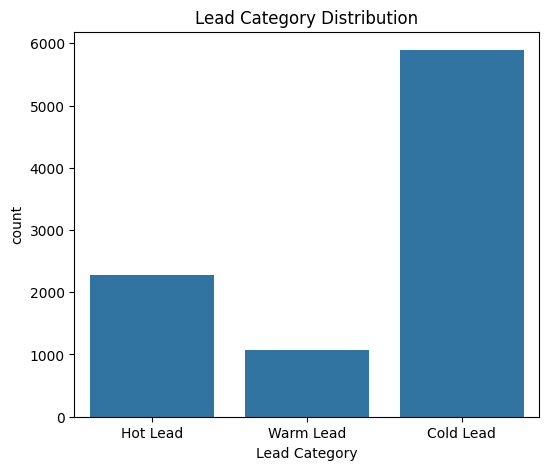

In [91]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Lead Category",
    order=["Hot Lead", "Warm Lead", "Cold Lead"]
)

plt.title("Lead Category Distribution")

plt.show()

# 📌 Business Recommendation

The sales team should:

- Immediately contact **Hot Leads**.
- Continue nurturing **Warm Leads** through emails and follow-ups.
- Include **Cold Leads** in long-term marketing campaigns rather than immediate sales efforts.

## 📊 Feature Importance Analysis

Understanding which features contribute the most to lead conversion is essential for both business decision-making and model interpretability.

After evaluating multiple machine learning models, **XGBoost** was selected as the final deployment model because it achieved the best overall performance, with the **highest ROC-AUC (92.35%)** while maintaining an excellent balance between **Accuracy, Precision, Recall, and F1-Score**.

One of the major advantages of tree-based ensemble models like **XGBoost** is their ability to estimate **feature importance**, enabling us to identify which variables have the greatest influence on predicting lead conversion.

Analyzing feature importance helps to:

- Identify the key factors influencing lead conversion.
- Understand which customer attributes contribute most to the model's predictions.
- Provide actionable business insights for the sales and marketing teams.
- Improve model transparency and interpretability.
- Support data-driven decision-making by highlighting the features that have the greatest impact on conversion probability.

The following visualization presents the **Top 15 most important features** learned by the **XGBoost** model during training, providing valuable insights into the factors that drive successful lead conversion.

In [92]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = best_model.named_steps["xgb_node"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
5,cat__Lead Origin_Lead Add Form,0.141984
147,cat__Last Notable Activity_SMS Sent,0.075216
125,cat__Lead Profile_Student of SomeSchool,0.070486
124,cat__Lead Profile_Potential Lead,0.059910
16,cat__Lead Source_Reference,0.048390
115,cat__Lead Quality_High in Relevance,0.036669
120,cat__Lead Quality_Worst,0.036209
117,cat__Lead Quality_Might be,0.032221
119,cat__Lead Quality_Unknown,0.031184
116,cat__Lead Quality_Low in Relevance,0.030050


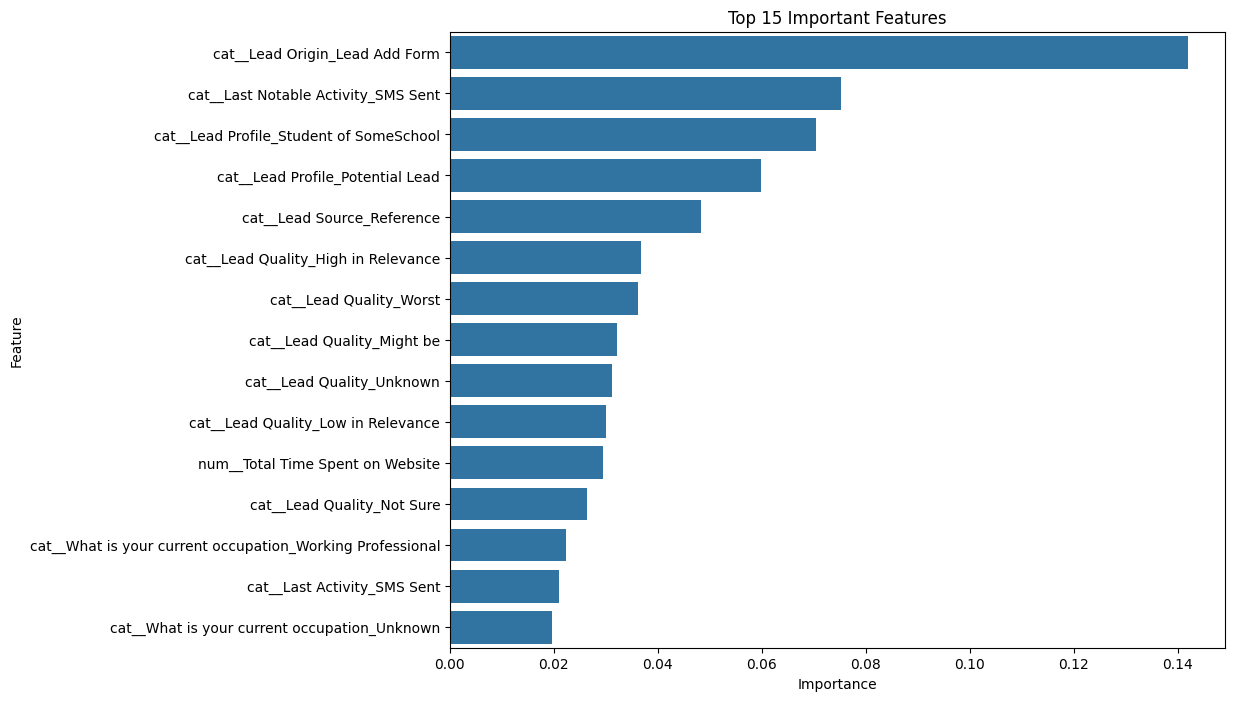

In [93]:
plt.figure(figsize=(10,8))

top_features = feature_importance.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.savefig(
    "/content/drive/MyDrive/Celebal_Final_Project/outputs/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📌 Observation

The plot highlights the features that contribute most to predicting lead conversion.

Features with higher importance have a greater influence on the model's prediction and should receive more attention from the business team.

# 📈 Business Insights

## 📈 Business Insights

Based on the feature importance analysis, the following business insights can be derived:

* **Lead Origin** is the most influential factor affecting lead conversion. In particular, leads generated through **Lead Add Form** exhibit the highest conversion potential, indicating that these leads are generally of higher quality and require immediate attention from the sales team.

* **Last Notable Activity**, especially **SMS Sent**, is a strong indicator of customer engagement. Leads that recently interacted through SMS are more likely to convert, making recent communication history an important factor for sales prioritization.

* **Lead Profile** significantly influences conversion probability. Prospects categorized as **Potential Lead** or **Student of SomeSchool** demonstrate distinct conversion patterns, enabling the sales team to segment and prioritize leads more effectively.

* **Lead Source**, particularly **Reference**, has a substantial impact on conversion. Referred leads generally have a higher likelihood of becoming customers, highlighting the value of referral-based marketing strategies.

* **Lead Quality** remains one of the strongest predictors of conversion. Categories such as **High in Relevance**, **Might be**, **Low in Relevance**, **Unknown**, **Not Sure**, and **Worst** strongly influence the model's predictions, emphasizing the importance of accurate lead qualification during the lead generation process.

* **Total Time Spent on Website** is an important behavioral indicator. Leads spending more time exploring the website typically show greater interest in the organization's offerings and have a higher probability of conversion.

* **Current Occupation** also contributes to lead conversion prediction. Occupation categories such as **Working Professional** and **Unknown** influence customer behavior, suggesting that professional background plays a role in purchasing decisions.

These insights enable the sales and marketing teams to identify high-potential leads more effectively, prioritize follow-up activities, optimize communication strategies, and allocate resources toward leads with the highest probability of conversion.


# ✅ Conclusion

This project successfully developed an **AI-powered Lead Scoring System** for X Education using Machine Learning to predict the likelihood of lead conversion and assist the sales team in prioritizing high-potential customers.

### Achievements

* Cleaned and preprocessed the dataset by handling missing values, removing duplicates, and encoding categorical features.
* Performed comprehensive Exploratory Data Analysis (EDA) to understand lead characteristics and customer behavior.
* Built and compared multiple machine learning models, including **Logistic Regression, Random Forest, Tuned Random Forest, SVM, LightGBM, and XGBoost**.
* Selected **XGBoost** as the final deployment model based on its superior overall performance, achieving the **highest ROC-AUC (92.35%)** while maintaining an excellent balance between Accuracy, Precision, Recall, and F1-Score.
* Achieved approximately **85.12% Accuracy**, **82.37% Precision**, **78.09% Recall**, **80.17% F1-Score**, and **92.35% ROC-AUC** on the test dataset.
* Generated **Lead Scores (0–100)** to estimate each lead's probability of conversion.
* Categorized leads into **Hot**, **Warm**, and **Cold** segments to support efficient sales prioritization.
* Identified the most influential factors affecting lead conversion, including **Lead Origin, Last Notable Activity, Lead Profile, Lead Source, Lead Quality, Total Time Spent on Website,** and **Current Occupation**.
* Developed an interactive **Streamlit dashboard** featuring individual lead prediction, batch prediction, lead analytics, feature importance visualization, business insights, and downloadable prediction reports.

The developed solution enables the sales and marketing teams to identify high-potential leads more effectively, prioritize follow-up activities, optimize resource allocation, improve customer engagement strategies, and make data-driven decisions that can ultimately increase lead conversion rates.


In [94]:
output_path = "/content/drive/MyDrive/Celebal_Final_Project/outputs/Lead_Scoring_Final_Output.csv"

df.to_csv(output_path, index=False)

print(f"Final dataset saved successfully at:\n{output_path}")

Final dataset saved successfully at:
/content/drive/MyDrive/Celebal_Final_Project/outputs/Lead_Scoring_Final_Output.csv
